# 含并行连结的网络（GoogLeNet）

## Inception块

In [5]:
# 导包
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Inception(nn.Module):
    # 参1：输入通道数；参2：第1个路径的输出通道数；参3：第2个路径的各层输出通道数；参4：第3个路径的各层输出通道数；参5：第4个路径的各层输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # 分支1
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size = 1)
        # 分支2
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size = 1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size = 3, padding = 1)
        # 分支3
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size = 1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size = 5, padding = 2)
        # 分支4
        self.p4_1 = nn.MaxPool2d(3, stride = 1,padding = 1)         # MaxPool2d默认步长是3，所以我们需要手动赋值
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size = 1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))                       # 路径1输出
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))    # 路径2输出
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))    # 路径3输出
        p4 = F.relu(self.p4_2(self.p4_1(x)))            # 路径4输出
        return torch.cat((p1, p2, p3, p4), dim = 1)      # 将4个路径输出按第1维度（通道）拼接

## GoogLeNet模型

In [6]:
b1 = nn.Sequential(         # Stage 1
    nn.Conv2d(1, 64, 7, 2, 3),
    nn.ReLU(),
    nn.MaxPool2d(3, 2, 1),
)

b2 = nn.Sequential(         # Stage 2
    nn.Conv2d(64, 64, 1),
    nn.ReLU(),
    nn.Conv2d(64, 192, 3, padding = 1),
    nn.ReLU(),
    nn.MaxPool2d(3, 2, 1)
)

b3 = nn.Sequential(         # Stage 3
    Inception(192, 64, (96, 128), (16, 32), 32),
    Inception(256, 128, (128, 192), (32, 96), 64),
    nn.MaxPool2d(3, 2, 1)
)

b4 = nn.Sequential(         # Stage 4
    Inception(480, 192, (96, 208), (16, 48), 64),
    Inception(512, 160, (112, 224), (24, 64), 64),
    Inception(512, 128, (128, 256), (24, 64), 64),
    Inception(512, 112, (144, 288), (32, 64), 64),
    Inception(528, 256, (160, 320), (32, 128), 128),
    nn.MaxPool2d(3, 2, 1)
)

b5 = nn.Sequential(         # Stage 5
    Inception(832, 256, (160, 320), (32, 128), 128),
    Inception(832, 384, (192, 384), (48, 128), 128),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 10))

## 为了使Fashion-MNIST上的训练短小精悍，我们将输入的高和宽从224降到96

In [7]:
X = torch.rand(size = (1, 1, 96, 96))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


## 训练模型

loss 0.242, train acc 0.908, test acc 0.891
1815.1 examples/sec on cuda:0


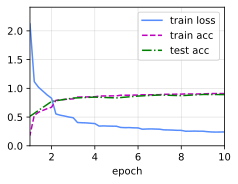

In [8]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize = 96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())